<a href="https://colab.research.google.com/github/BramSimonnet/Deep-Learning-Homework/blob/main/problem5diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion

Diffusion is a technique for *generating* new images. In the diffusion process, we begin with random pixels and repeatedly remove "noise" from the image until we are left with an image we recognize. Ideally, the process would look something like the following: A cat on a bike slowly appears from random noise.

![](https://www.rtealwitter.com/deeplearning2023/images/noise-to-image.png)

Of course, removing such noise from an image is ostensibly a difficult task: How does the model know what noise to remove at each step? And how do we get training data? The key observation of diffusion is that, while going from noise to an image is challenging, going from an image to noise is quite easy: If we begin the process with a real image we already have, then we can add random noise to the image until the result becomes unrecognizable.

![](https://www.rtealwitter.com/deeplearning2023/images/image-to-noise.png)

Operationally, we provide one noisy image and train the model to predict the noise that was last added to it. Let's formulize the process in our three step recipe for machine learning:

1. **Model**. The model is an architecture that takes in a noisy image and predicts what noise was last applied.

2. **Loss**. The loss is the difference between the predicted noise and the actual noise. Of course, since we added the noise to the image, we actually do know what noise was last added and directly compare it to the prediction. We'll use the mean squared difference between the two as our loss criterion.

3. **Optimizer**. As usual, we run gradient descent on the parameter space of the model to minimize the loss.

In this lab, we will train a diffusion model on the MNIST data set. After getting a sense for how diffusion works, we will load pretrained models for *stable diffusion* and run them on prompts of your choice.



## Diffusion on MNIST

We will build a diffusion model on the relatively simpler data set of handwritten images.

As usual, we will load several helpful libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

### MNIST

The MNIST data set consists of $28 \times 28$ black-and-white images with handwritten digits. We will download the training set and count the number of images in the data set.

In [2]:
train_data = torchvision.datasets.FashionMNIST(
    'dataset',
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor()
)

print(f'There are {len(train_data)} images in the training set!')

100%|██████████| 26.4M/26.4M [01:27<00:00, 302kB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 1.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.6MB/s]

There are 60000 images in the training set!


Since there are 60k images in the training set, we'll need a way to train on *batches* of them. For this purpose, we'll use the pytorch `DataLoader` and specify a batch size of 512 (we love powers of two and it [may help](https://stackoverflow.com/questions/44483233/is-using-batch-size-as-powers-of-2-faster-on-tensorflow) with parallelization).

In [3]:
batch_size = 512

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)

Before we begin building the architecture, let's take a look at the images in the data set.

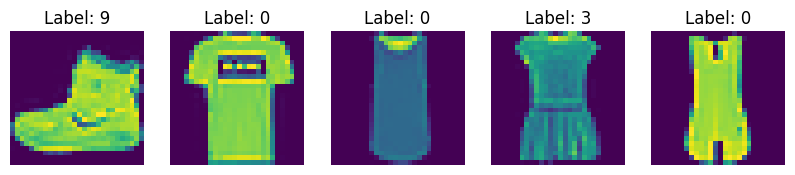

In [4]:
images, labels = next(iter(train_loader)) # load from the dataloader

plt.figure(figsize=(10,4))
for index in np.arange(0,5):
  plt.subplot(1,5,index+1)
  plt.axis('off')
  plt.title(f'Label: {labels[index].item()}')
  plt.imshow(images[index].squeeze().numpy())

As promised, we have handwritten digits that resemble numbers. As a sanity check, what is the shape of `images` as defined above?

In [5]:
# Check that the shape of images makes sense.
# (batch_size, 1, 28, 28)
images.shape

torch.Size([512, 1, 28, 28])

The first step of diffusion is to generate the training data. We'll draw the random noise from the normal distribution. However, we'll have to choose the standard deviation of the noise and how many steps of noise to apply. In order to choose appropriate values, let's plot what the noising process does.

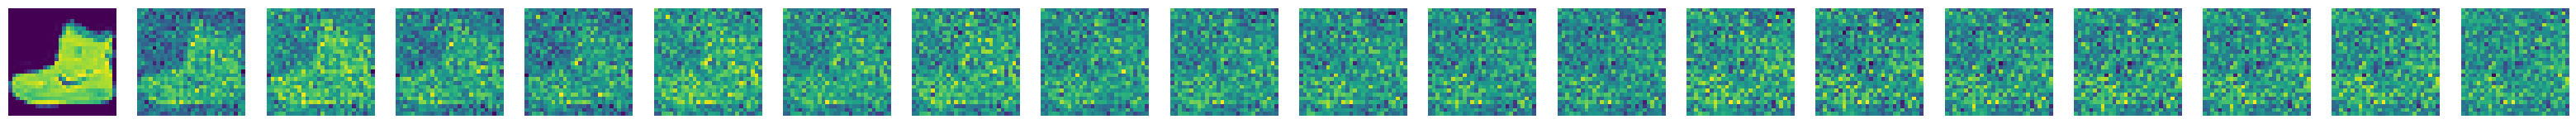

In [6]:
images, labels = next(iter(train_loader))
noisy_images = images

# The two hyperparameters we are choosing.
sigma = .35 # standard deviation
noise_steps = 20 # number of steps we apply noise

plt.figure(figsize=(noise_steps * 2, 10))
for i in range(noise_steps):
  # Draw noise from a normal distribution with standard deviation sigma.
  noise = torch.normal(0, sigma, images.shape)
  plt.subplot(1,noise_steps,i+1)
  plt.imshow(noisy_images[0].squeeze())
  plt.axis('off')
  # Add the noise to the image.
  noisy_images = noise + noisy_images

After playing with the hyperparemeters, I set `sigma`=.35 and `noise_steps`=20. I chose these values with the following considerations in mind:

* Since the diffusion process will begin with noise, it's important that the training data includes noisy images that look like noise (i.e. no indication of the starting image).

* Simultaneously, there should be lots of images where the starting image is somewhat apparent. In this way, we train the model to remove noise both on images that look like noise *and* images that somewhat resemble the underlying image.

Of course, there are lots of other hyperparameter pairs that satisfy these constraints and you are welcome to explore for them.

### Architecture

Training a diffusion model is particularly finicky. To make this model work, there are several hacks that I employed:

* The output of the diffusion model is normalized to have mean 0 and standard deviation `sigma`. The reasoning is that this makes the output more closely resemble noise so we can make the training process faster.

* In addition to the image, the model takes in the number of noise steps that have been applied to the image. This gives it information on how much noise it should expect. Intuitively, this makes its task easier since the noise it removes should depend on how much noise has been added.

* The model takes in the label of the image. This extra information guides it through the diffusion process: for example, removing noise from a 9 is a different task than removing noise from a 7.

I found that each of these additions was necessary to training a successful diffusion model efficiently. If you are feeling adventurous, you're welcome to try removing these additions and/or adding your own.

Let's begin by defining the normalization function. We're simplying going to subtract the mean, divide by the standard deviation, and multiply by `sigma`. However, because we are applying this operation to each image separately in a batch, we need to be slightly careful about the dimensions.

In [7]:
def normalize(x, sigma):
  # x is (batch_size, 28*28)
  mean = x.mean(dim=-1).view(-1, 1)
  # mean is (batch_size, 1) i.e. a different mean for each image
  std = x.std(dim=-1).view(-1,1)
  # std is (batch_size, 1) i.e. a different standard deviation for each image
  return (x-mean) / std * sigma

We're now ready to define the diffusion architecture. Note that we will pass in they hyperparameters `sigma` and `noise_steps` when we initialize the model. In addition, we will actually use a very simple two layer linear architecture. There will be about $(28 \cdot 28)^2 = 614656$ parameters which, since the images are small, is relatively mangeable. When we pass them in, we will [one-hot](https://en.wikipedia.org/wiki/One-hot) the amount of noise and the number of labels.

In [8]:
class Diffuser(nn.Module):
  def __init__(self, sigma, noise_steps):
    super(Diffuser, self).__init__()
    # Recall the input is the image,
    # the amount of noise applied (this will be one-hot encoded),
    # and the number of labels (this will also be one-hot encoded).
    self.layers = nn.Sequential(
      nn.Linear(28*28+noise_steps+10, 28*28),
      nn.ReLU(),
      nn.Linear(28*28, 28*28)
    )
    self.sigma = sigma
    self.noise_steps = noise_steps

  def forward(self, images, noise_level, labels):
    # Convert image from (batch_size, 1, 28, 28) to (batch_size, 28*28) using .view
    images = images.view(-1, 28*28)
    # Combine the image with the noise level and labels.
    # We one hot encode both using F.one_hot
    noise_level_encoding = F.one_hot(
        torch.tensor([noise_level]*images.shape[0]), num_classes = self.noise_steps
    ).to(device)
    labels_encoding = F.one_hot(labels, num_classes = 10).to(device)
    # Concatenate the three inputs in a batch of long vectors
    x = torch.cat((images, noise_level_encoding, labels_encoding), 1)
    # The shape should now be (batch_size, 28*28+noise_steps+10)
    # Feed the input through the layers.
    x = self.layers(x)
    # Normalize x using our normalize function
    x = normalize(x, self.sigma)
    # Reformat the output so it is (batch_size, 1, 28, 28) using .view
    x = x.view(-1, 1, 28, 28)
    return x

Now we are ready to initialize the model, optimizer, and criterion. So that we can train faster on the GPU, we will also define the device. To use the GPU on colab, make sure that Runtime > Change runtime type > Hardware accelerator is on GPU.

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Diffuser(sigma, noise_steps).to(device)
optimizer = torch.optim.Adam(model.parameters(), 1)
criterion = nn.MSELoss()

We'll also want to sample noise efficiently on the GPU. To do this, we'll define a normal distribution with standard deviation `sigma`.

In [10]:
# Define unit_normal as an instance of torch.distributions.Normal
# and put its parameters (loc and scale) on the device.
unit_normal = torch.distributions.Normal(0, sigma)
unit_normal.loc = unit_normal.loc.to(device)
unit_normal.scale = unit_normal.scale.to(device)

So that we can visualize how the model is doing during training, let's write an evaluation function. The function will sample random noise and, guided by each label, use the model to repeatedly remove noise from the image for `noise_steps` iterations.

The initial noise will be sampled from a mean-centered normal distribution with standard deviation `sigma` `noise_steps`^1/2. (This is because of a [special property](https://en.wikipedia.org/wiki/Sum_of_normally_distributed_random_variables#:~:text=This%20means%20that%20the%20sum,squares%20of%20the%20standard%20deviations) of the sum of normal distributions.)

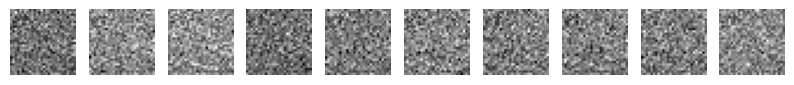

In [11]:
def evaluate(model, noise_steps):
    model.eval()

    # Sample noisy images
    noisy_images = unit_normal.sample((10, 1, 28, 28)) * np.sqrt(noise_steps)
    noisy_images = noisy_images.to(device)

    # Initialize labels 0 through 9
    labels = torch.tensor([i for i in range(10)]).to(device)

    plt.figure(figsize=(10, 5))

    # Remove noise from the images
    for noise_step in range(noise_steps):
        noise_level = noise_steps - noise_step - 1
        with torch.no_grad():
            noise = model(noisy_images, noise_level, labels)
        noisy_images -= noise

    # Plot the resulting images
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(noisy_images[i].cpu().squeeze().numpy(), cmap='gray')
        plt.axis('off')

    plt.show()
    model.train()

evaluate(model, noise_steps)

As we expect, the untrained model just produces noise. Let's see if we can do any better after training.

### Training

We will now train the model! For each batch in each epoch, we will try different noise levels in a random order (this is to randomize the gradient descent updates). Using the variance trick for normal distributions, we can sample a noisy image after `noise_level` steps of `sigma` noise simply by sampling from a distribution with standard deviation `sigma` `noise_level`^1/2.

Epoch: 0 	 Loss: 463.4666360318661


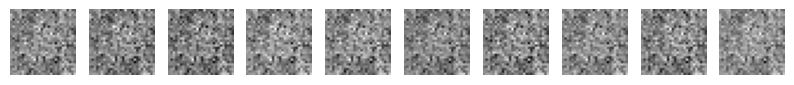

Epoch: 1 	 Loss: 411.28937428444624


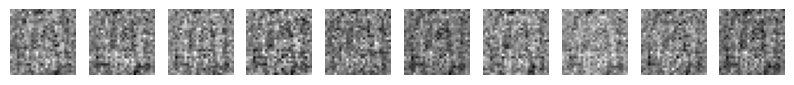

Epoch: 2 	 Loss: 399.24333930388093


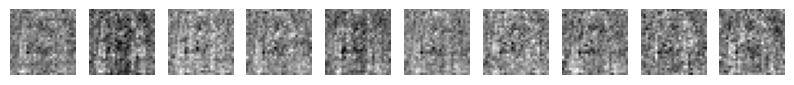

Epoch: 3 	 Loss: 392.2572697326541


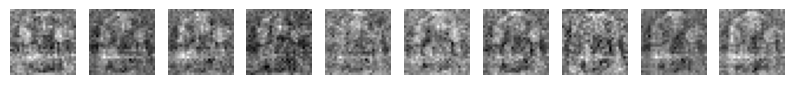

Epoch: 4 	 Loss: 385.7210847698152


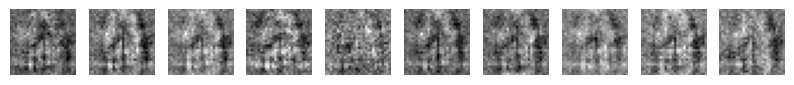

Epoch: 5 	 Loss: 381.93934999778867


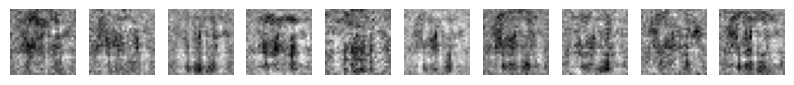

Epoch: 6 	 Loss: 379.6090467572212


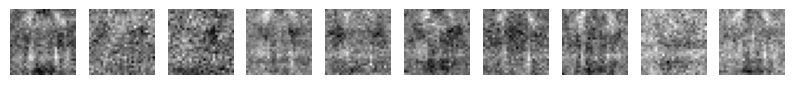

Epoch: 7 	 Loss: 377.7844303883612


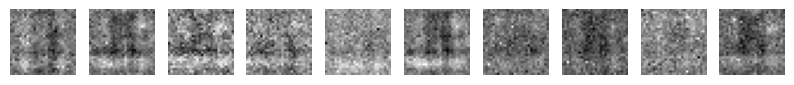

Epoch: 8 	 Loss: 376.6519643496722


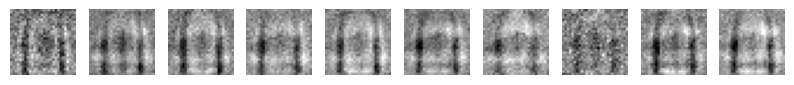

Epoch: 9 	 Loss: 376.19986143894494


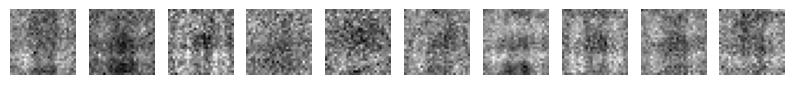

Epoch: 10 	 Loss: 375.5863079056144


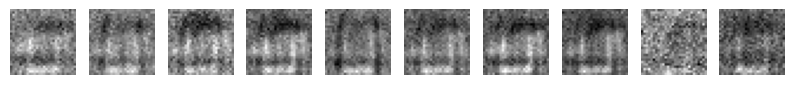

Epoch: 11 	 Loss: 374.6221186518669


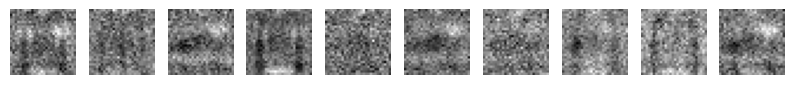

Epoch: 12 	 Loss: 373.78705363348126


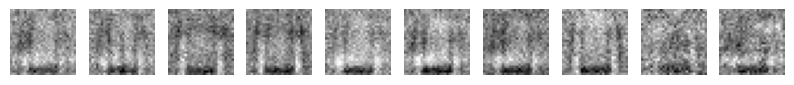

Epoch: 13 	 Loss: 373.84729875065386


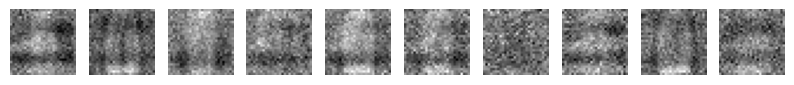

Epoch: 14 	 Loss: 373.09961457177997


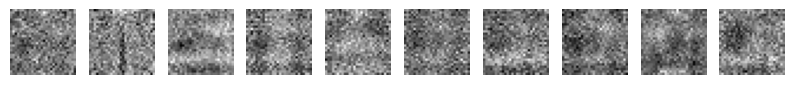

Epoch: 15 	 Loss: 373.05898277647793


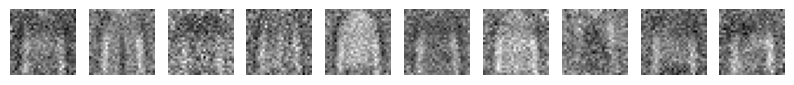

Epoch: 16 	 Loss: 372.90125752054155


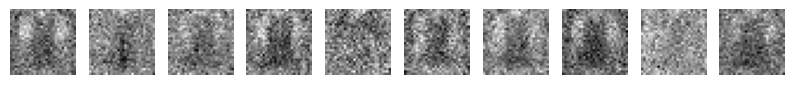

Epoch: 17 	 Loss: 372.74934113770723


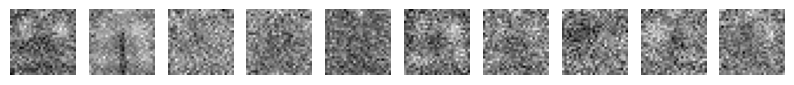

Epoch: 18 	 Loss: 371.8474059496075


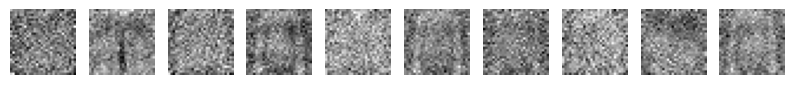

Epoch: 19 	 Loss: 371.60836581140757


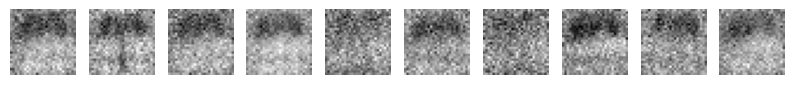

Epoch: 20 	 Loss: 371.6700819451362


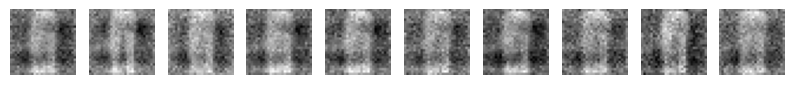

Epoch: 21 	 Loss: 370.9368922691792


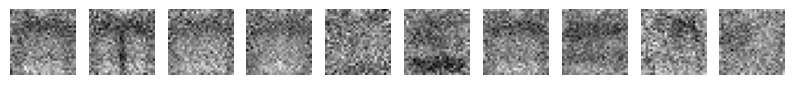

Epoch: 22 	 Loss: 371.3378220126033


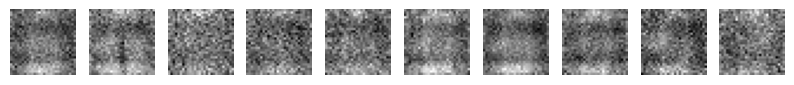

Epoch: 23 	 Loss: 370.7695368155837


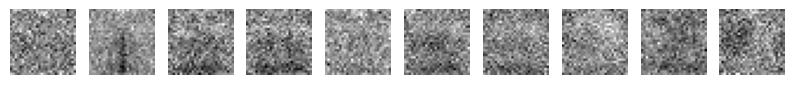

Epoch: 24 	 Loss: 370.6458991263062


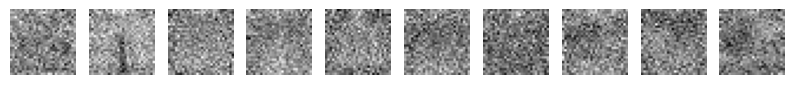

In [12]:
num_epochs = 25
epoch_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        for noise_level in torch.randperm(noise_steps):
            noise_level = noise_level.item()

            # Build the less noisy image using the variance trick
            less_noisy = images + unit_normal.sample(images.shape) * np.sqrt(noise_level)

            # One additional step of noise
            one_step_noise = unit_normal.sample(images.shape)

            # Generate the more noisy image
            more_noisy = less_noisy + one_step_noise

            # Predict the one-step noise
            output = model(more_noisy, noise_level, labels)

            # Mean squared error between predicted and true noise
            loss = criterion(output, one_step_noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

    epoch_losses.append(epoch_loss)
    print(f'Epoch: {epoch} \t Loss: {epoch_loss}')
    evaluate(model, noise_steps)

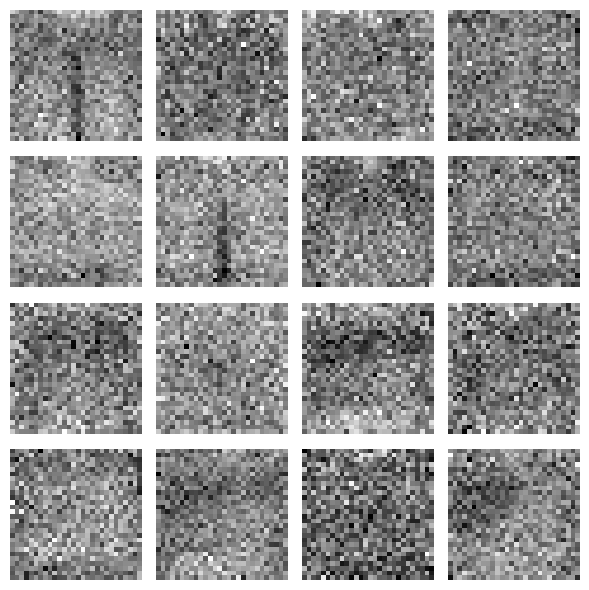

In [13]:
def generate_4x4(model, noise_steps):
    model.eval()

    noisy_images = unit_normal.sample((16, 1, 28, 28)) * np.sqrt(noise_steps)
    noisy_images = noisy_images.to(device)

    labels = torch.randint(0, 10, (16,)).to(device)

    for noise_step in range(noise_steps):
        noise_level = noise_steps - noise_step - 1
        with torch.no_grad():
            noise = model(noisy_images, noise_level, labels)
        noisy_images -= noise

    plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(noisy_images[i].cpu().squeeze().numpy(), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    model.train()

generate_4x4(model, noise_steps)

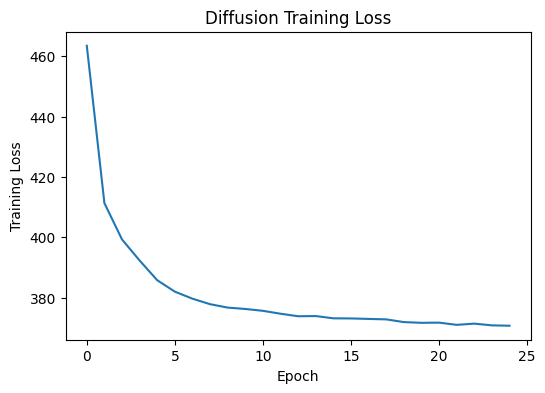

In [14]:
plt.figure(figsize=(6,4))
plt.plot(epoch_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Diffusion Training Loss")
plt.show()

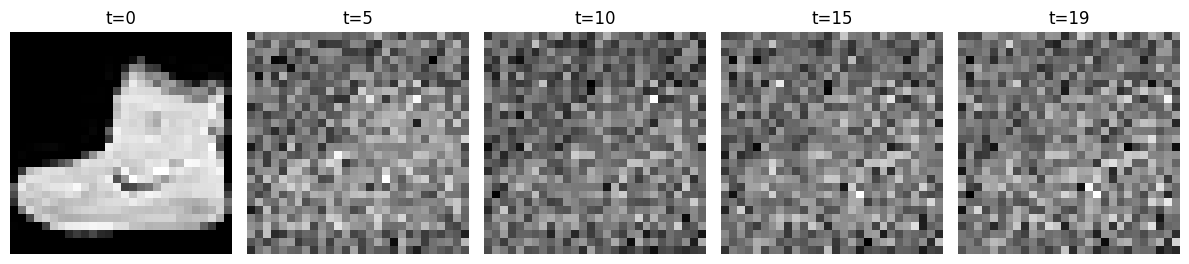

In [15]:
images, labels = next(iter(train_loader))
image = images[0:1]   # take one image
noisy_image = image.clone()

sigma = 0.35
noise_steps = 20
selected_steps = [0, 5, 10, 15, 19]

plt.figure(figsize=(12, 3))

for t in range(noise_steps):
    if t > 0:
        noise = torch.normal(0, sigma, image.shape)
        noisy_image = noisy_image + noise

    if t in selected_steps:
        plt.subplot(1, len(selected_steps), selected_steps.index(t) + 1)
        plt.imshow(noisy_image[0].squeeze().numpy(), cmap='gray')
        plt.title(f't={t}')
        plt.axis('off')

plt.tight_layout()
plt.show()

**(b) Forward diffusion visualization**

To visualize the forward diffusion process, I repeatedly added Gaussian noise to a FashionMNIST image and plotted the result at several timesteps ($t = 0, 5, 10, 15, 19$). At early timesteps, the clothing item is clearly recognizable, but the edges and fine details degrade quickly as noise is added. By intermediate timesteps, the overall shape becomes difficult to distinguish, and at later timesteps the image is almost entirely random noise.

The most sensitive components to noise are the edges and fine structural details, which disappear first. Coarser intensity patterns and general shapes persist slightly longer, but eventually all structure is lost as the noise dominates the image.

In [16]:
def linear_scale(noise_level, noise_steps):
    return np.sqrt(noise_level)

def quadratic_scale(noise_level, noise_steps):
    return noise_level / np.sqrt(noise_steps)

In [17]:
def train_diffusion_with_schedule(schedule_fn, num_epochs=10):
    model = Diffuser(sigma, noise_steps).to(device)
    optimizer = torch.optim.Adam(model.parameters(), 1)
    criterion = nn.MSELoss()
    epoch_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            for noise_level in torch.randperm(noise_steps):
                noise_level = noise_level.item()

                scale = schedule_fn(noise_level, noise_steps)

                less_noisy = images + unit_normal.sample(images.shape) * scale
                one_step_noise = unit_normal.sample(images.shape)
                more_noisy = less_noisy + one_step_noise

                output = model(more_noisy, noise_level, labels)
                loss = criterion(output, one_step_noise)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

        epoch_losses.append(epoch_loss)
        print(f"Epoch {epoch}: Loss {epoch_loss}")

    return model, epoch_losses

In [18]:
linear_model, linear_losses = train_diffusion_with_schedule(linear_scale, num_epochs=10)
quadratic_model, quadratic_losses = train_diffusion_with_schedule(quadratic_scale, num_epochs=10)

Epoch 0: Loss 460.06209157407284
Epoch 1: Loss 407.9119082130492
Epoch 2: Loss 395.6571135520935
Epoch 3: Loss 388.81420164369047
Epoch 4: Loss 384.3230488970876
Epoch 5: Loss 381.7737363111228
Epoch 6: Loss 380.28361409530044
Epoch 7: Loss 377.91350586898625
Epoch 8: Loss 377.0429554358125
Epoch 9: Loss 375.6855398211628
Epoch 0: Loss 419.5371387079358
Epoch 1: Loss 354.42637583613396
Epoch 2: Loss 340.9142501838505
Epoch 3: Loss 333.37474324181676
Epoch 4: Loss 326.0199490841478
Epoch 5: Loss 320.49847011454403
Epoch 6: Loss 317.14120880141854
Epoch 7: Loss 313.393648378551
Epoch 8: Loss 311.6012608371675
Epoch 9: Loss 310.7189750187099


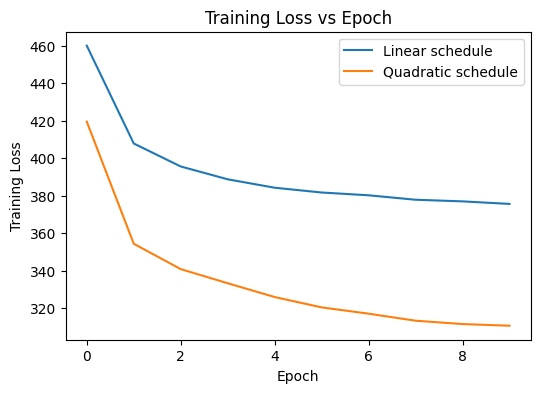

In [19]:
plt.figure(figsize=(6,4))
plt.plot(linear_losses, label='Linear schedule')
plt.plot(quadratic_losses, label='Quadratic schedule')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.show()

In [20]:
def generate_4x4_from_model(model, noise_steps):
    model.eval()

    noisy_images = unit_normal.sample((16, 1, 28, 28)) * np.sqrt(noise_steps)
    noisy_images = noisy_images.to(device)
    labels = torch.randint(0, 10, (16,)).to(device)

    for noise_step in range(noise_steps):
        noise_level = noise_steps - noise_step - 1
        with torch.no_grad():
            noise = model(noisy_images, noise_level, labels)
        noisy_images -= noise

    plt.figure(figsize=(6,6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(noisy_images[i].cpu().squeeze().numpy(), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    model.train()

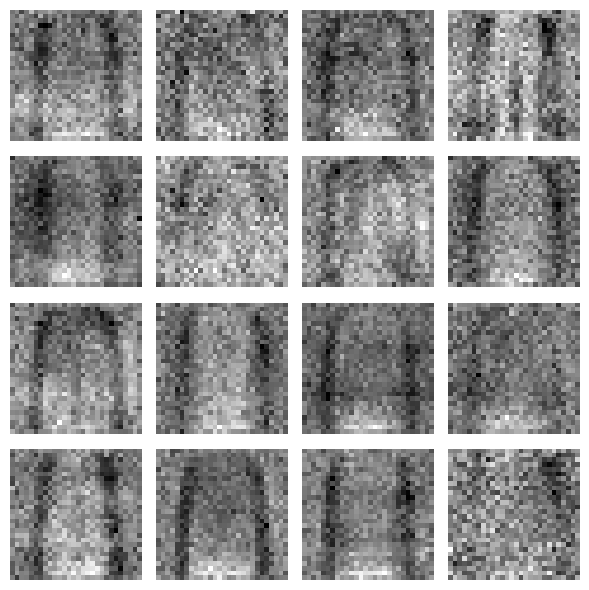

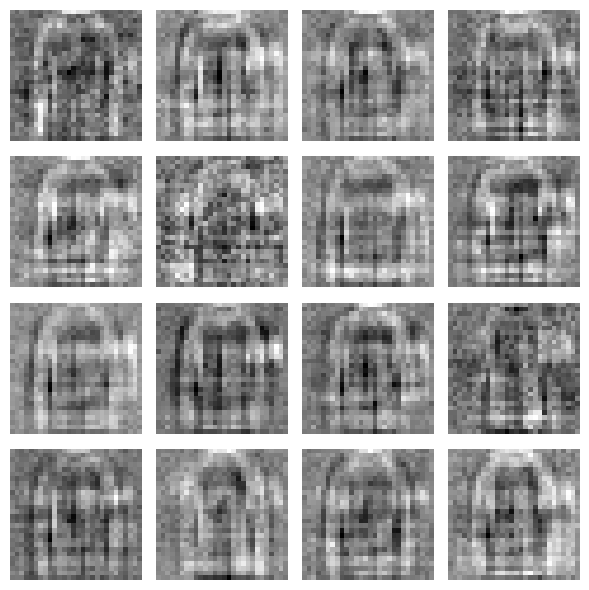

In [21]:
generate_4x4_from_model(linear_model, noise_steps)
generate_4x4_from_model(quadratic_model, noise_steps)

# **(c) Noise ablation on diffusion**

I compared a linear noise schedule to a nonlinear quadratic schedule while keeping the number of diffusion steps fixed. The training loss curves show that the quadratic schedule converges faster and achieves a significantly lower final loss than the linear schedule.

This difference arises because the quadratic schedule adds noise more gradually at early timesteps and more aggressively at later timesteps. As a result, the model first learns to denoise lightly corrupted images before handling heavily corrupted ones, making optimization easier. In contrast, the linear schedule introduces noise more uniformly across timesteps, making the denoising task consistently difficult.

In the generated samples, both models produce noisy and blurry outputs due to the simplicity of the architecture. However, the quadratic schedule produces more structured and consistent images, with clearer vertical patterns resembling clothing items, whereas the linear schedule outputs are more noisy and less coherent. This demonstrates that the noise schedule plays an important role in both training dynamics and sample quality.

# **(d) GAN vs Diffusion**

**Sample quality and diversity.**

The diffusion model produces samples that are generally more structured than those from the standard GAN, although both models generate somewhat noisy and blurry images due to their simplicity. Compared to the GAN, diffusion outputs tend to exhibit smoother patterns and more gradual structure formation, while GAN outputs can appear more fragmented or inconsistent. However, neither approach produces highly sharp images in this setting.

**Training behavior and stability.**

The diffusion model is significantly more stable during training. Its objective is a simple mean squared error between predicted and true noise, which leads to smooth and consistent optimization. In contrast, GAN training is known to be unstable due to the adversarial setup between generator and discriminator, often requiring careful tuning to avoid issues such as mode collapse or oscillations.

**Controllability.**

Both the conditional GAN and the diffusion model incorporate label information, allowing for class-specific generation. However, diffusion models use this conditioning more effectively across multiple denoising steps, leading to more consistent incorporation of label information throughout the generation process.

**Overall comparison.**

GANs are generally faster to generate samples since they require only a single forward pass, while diffusion models are slower because they iteratively remove noise over many steps. However, diffusion models offer improved stability and often produce more coherent outputs. In this experiment, diffusion demonstrates more reliable training behavior and slightly better structure in generated images, while GANs provide faster but less stable generation.